In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re
import random
from scipy.stats import loguniform

# For plotting contours
from scipy.stats import gaussian_kde
import matplotlib.gridspec as gridspec

import os

%config InlineBackend.figure_format = 'retina'
%config InlineBackend.rc = {'figure.figsize': (6, 4)}

In [2]:
samples = loguniform.rvs(1e-4, 1e-1, size=1000)
print(samples.min(), samples.max(), np.median(samples))

0.00010001102865671618 0.09985294193243549 0.00268743174432473


In [3]:
from src.load_data import load_ishigaki, load_hw2002, load_ishigaki_selected, load_takahashi, load_ww95, load_limongi18

from src.utils import _isotope_to_element, _isotope_label, _combine_elements, extract_yield_peaks
from params import filter_elements, f_star_by_f_dil

from src.plot import plot_yields, plot_one_yield

from src.salvadori_funcs import salvadori_Zism, salvadori_abundance_ratio, salvadori_H_ratio, salvadori_combined_abundratio,salvadori_combined_abundratio_WrtH
from src.salvadori_funcs import salvadori_yields as salvadori_yields_convert
from src.formulas import abundance_ratio


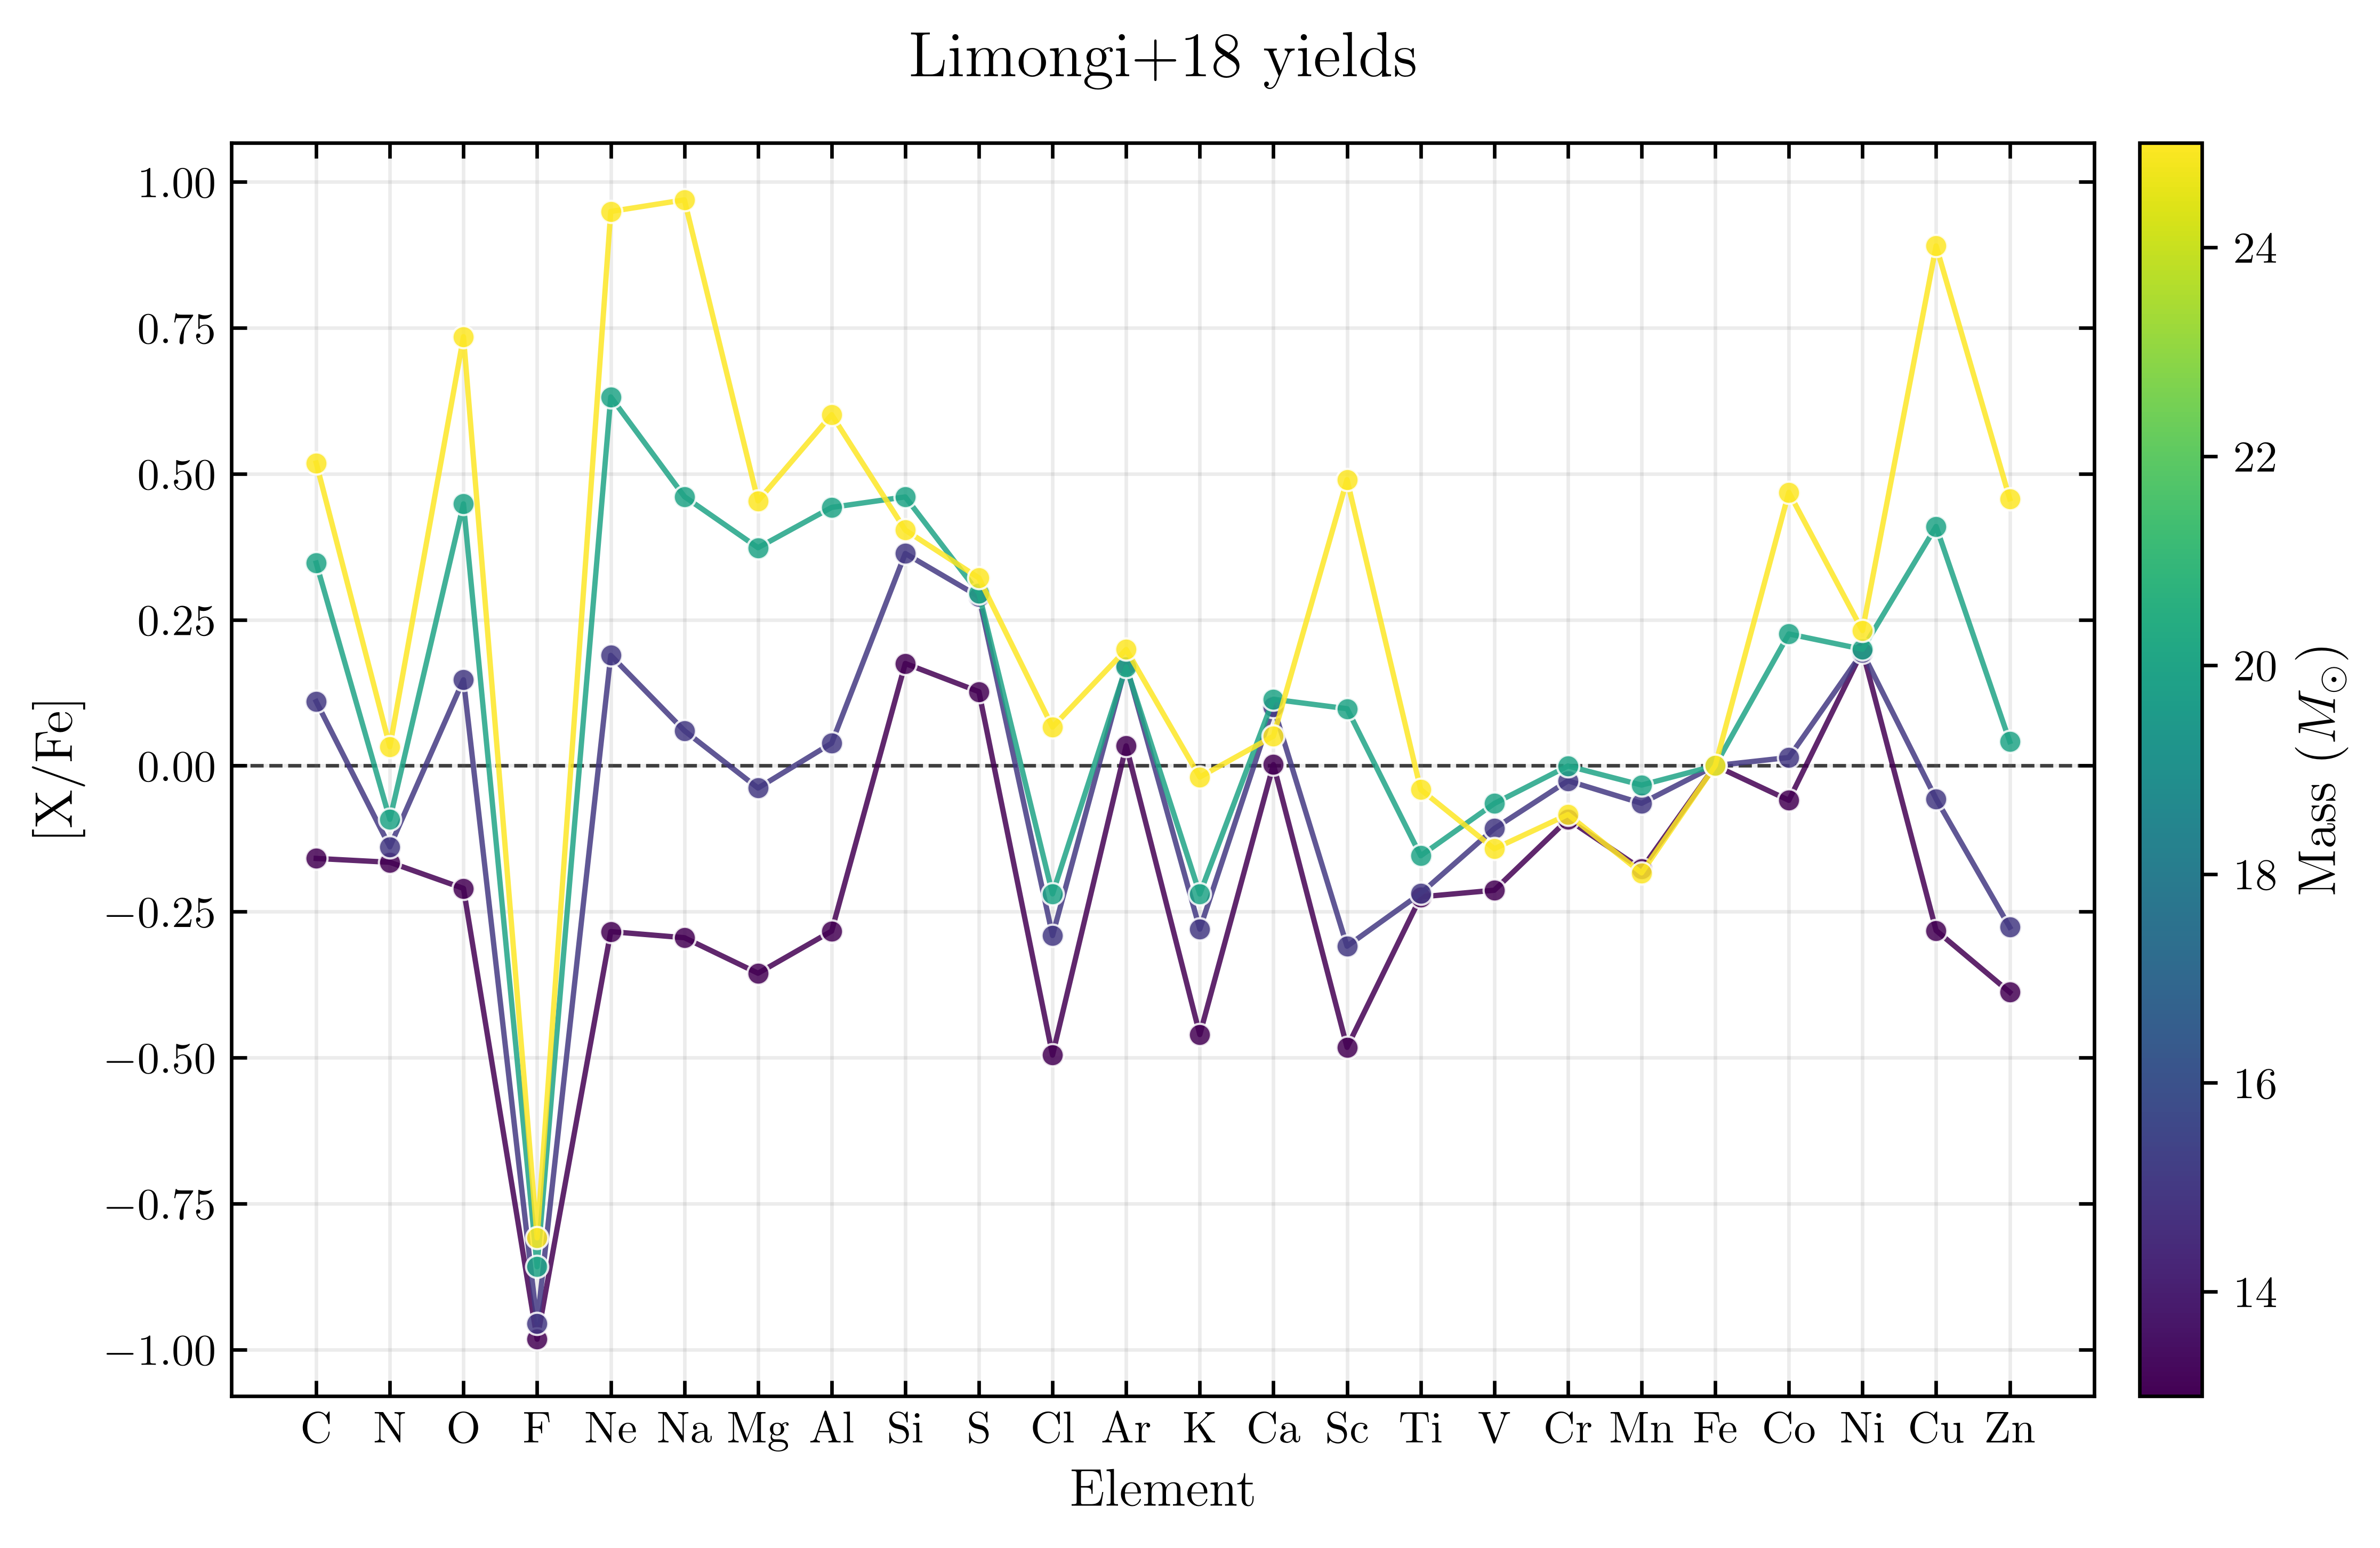

<Axes: title={'center': 'Limongi+18 yields'}, xlabel='Element', ylabel='[$\\mathrm{X} / \\mathrm{Fe}$]'>

In [13]:
limongi18 = load_limongi18()

limongi18 = [e for e in limongi18 if e['params']['velocity'] == 0 and e['params']['feh'] == 0 and e['params']['mass'] <= 25]

plot_yields(limongi18 , filter_elements=filter_elements, title="Limongi+18 yields") 

In [ ]:
ishigaki18_yields = load_ishigaki()
hw_yields = load_hw2002()
ishigaki18_selected_yields = load_ishigaki_selected() # NOTE: already summed isotopes
takahashi_yields = load_takahashi()
takahashi_yields = takahashi_yields["NR"] # NOTE: only use non-rotating models for now
ww95_yields = load_ww95()
 

In [ ]:
# ishigaki18_selected_yields = [entry for entry in ishigaki18_selected_yields if entry["params"]["mass"] in [25, 40]]
# ishigaki18_selected_yields[0]

In [ ]:
hw_yields = hw_yields[1:]

# for entry in hw_yields:
#     entry['yields'] = _combine_elements(entry['yields'])

In [ ]:
salvadori_yields = salvadori_yields_convert(hw_yields)

for entry in salvadori_yields:
    entry['yields'] = _combine_elements(entry['yields'])

In [ ]:
pisn_yields = salvadori_yields
# sn_yields = ishigaki18_selected_yields
sn_yields = ww95_yields
# sn_yields = [entry for entry in sn_yields if entry["params"]["lfej"] >= 0.0]

for elem in ["Cu", "Zn", "N"]:
    if elem in ["H", "He", "P", "Fe"]:
        continue

    print(f"Processing element: {elem}")

    X_Fe = []
    Fe_H = []
    for i in range(1000):
        pisn_entry = random.choice(pisn_yields)
        sn_entry = random.choice(sn_yields)

        f_pisn = 0.9
        f_ratio = loguniform.rvs(1e-4, 1e-1)
        tpop2_values = [3e6, 10e6, 20e6, 30e6]
        tpop2 = random.choice(tpop2_values)  # 10 Myr

        pisn_details = {
            "mass": pisn_entry["params"]["mass"],
        }
        # sn_details = {
        #     "mass": sn_entry["params"]["mass"],
        #     "model": sn_entry["params"]["model"],
        #     # "lfej": sn_entry["params"]["lfej"],
        #     # "energy": sn_entry["params"]["energy"],
        #     "elem_value": sn_entry["yields"].get(elem, 0.0),
        #     "Fe_value": sn_entry["yields"].get("Fe", 0.0),
        # }

        combined_ratio = salvadori_combined_abundratio(elem,elem,"Fe","Fe", pisn_entry, sn_yields, f_pisn=f_pisn, f_ratio=f_ratio, tpop2=tpop2)
        combined_ratio_wrtH = salvadori_combined_abundratio_WrtH("Fe","Fe", pisn_entry, sn_yields, f_pisn=f_pisn, f_ratio=f_ratio, tpop2=tpop2)

        if combined_ratio < -5 or combined_ratio_wrtH < -5:
        # if sn_entry["yields"].get(elem, 0.0) < 1e-6:
            
            print("Very low ratio detected")
            print("Elem", elem,"\n", "PISN", pisn_details, "\n", "SN", "_NA_", "\n", "Combined Ratio", combined_ratio, "\n", "Combined Ratio w.r.t H", combined_ratio_wrtH)
            print("-------------------------------")
            #continue # do not add to the list if the ratio is very low, but print details for debugging

        X_Fe.append(combined_ratio)
        Fe_H.append(combined_ratio_wrtH)

    def plot_density_with_marginals(feh_vals, xfe_vals, elem, f_pisn, save_path=None):
        feh_vals = np.array(feh_vals)
        xfe_vals = np.array(xfe_vals)

        mask = np.isfinite(feh_vals) & np.isfinite(xfe_vals)
        feh_vals, xfe_vals = feh_vals[mask], xfe_vals[mask]

        xy = np.vstack([feh_vals, xfe_vals])
        kde = gaussian_kde(xy)

        xmin, xmax = feh_vals.min(), feh_vals.max()
        ymin, ymax = xfe_vals.min(), xfe_vals.max()
        xpad = 0.05 * (xmax - xmin)
        ypad = 0.05 * (ymax - ymin)

        Xg, Yg = np.mgrid[xmin-xpad:xmax+xpad:200j, ymin-ypad:ymax+ypad:200j]
        positions = np.vstack([Xg.ravel(), Yg.ravel()])
        Z = np.reshape(kde(positions).T, Xg.shape)

        fig = plt.figure(figsize=(6, 6))
        gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                                wspace=0.05, hspace=0.05)

        ax_main = fig.add_subplot(gs[1, 0])
        ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
        ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

        cs = ax_main.contourf(Xg, Yg, Z, levels=20, cmap='inferno')
        ax_main.set_xlabel("[Fe/H]")
        ax_main.set_ylabel(f"[{elem}/Fe]")

        ax_top.hist(feh_vals, bins=40, density=True, color='gray')
        ax_top.tick_params(labelbottom=False, labelleft=False)
        ax_top.set_ylabel("P(x)")

        ax_right.hist(xfe_vals, bins=40, density=True, orientation='horizontal', color='gray')
        ax_right.tick_params(labelbottom=False, labelleft=False)
        ax_right.set_xlabel("P(y)")

        ax_top.set_title(f"f_pisn = {f_pisn:.2f}")

        if save_path:
            fig.savefig(save_path, dpi=300)
        plt.close(fig)

    plot_density_with_marginals(Fe_H, X_Fe, elem, f_pisn,
                                save_path=f"plots/abundance_scatter_contour/{elem}_contour.png")
        
    # X_Fe = [x for x in X_Fe if x > -5]
    # Fe_H = [Fe_H[i] for i in range(len(X_Fe)) if X_Fe[i] > -5]
    plt.scatter(Fe_H, X_Fe, alpha=0.5, color='black')
    plt.xlabel("[Fe/H]")
    plt.ylabel("[" + elem + "/Fe]")
    plt.title("f_pisn = " + str(f_pisn) + ", f_ratio = " + str(f_ratio))
    # plt.show()
    f_ratio_str = f"{f_ratio:.0e}".replace("e-0", "e-").replace("e+0", "e+")
    # plt.savefig("plots/f_pisn_" + str(int(f_pisn*100)) + "_f_ratio_" + f_ratio_str + "/" + elem + "_scatter.png", dpi=300)
    plt.savefig(f"plots/abundance_scatter/{elem}_scatter.png", dpi=300)
    plt.clf()
        

Processing element: Cu


/home/ardo/mlem/Vaults/Thesis/Repl/src/salvadori_funcs.py:400: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return quad(
/home/ardo/mlem/Vaults/Thesis/Repl/src/salvadori_funcs.py:343: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.

Processing element: Zn


/home/ardo/mlem/Vaults/Thesis/Repl/src/salvadori_funcs.py:400: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return quad(
/home/ardo/mlem/Vaults/Thesis/Repl/src/salvadori_funcs.py:400: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return quad(


Processing element: N


/home/ardo/mlem/Vaults/Thesis/Repl/src/salvadori_funcs.py:400: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return quad(
/home/ardo/mlem/Vaults/Thesis/Repl/src/salvadori_funcs.py:343: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.

<Figure size 1920x1440 with 0 Axes>

In [ ]:
pisn_yields = takahashi_yields
sn_yields = ishigaki18_selected_yields

def plot_density_with_marginals(feh_vals, xfe_vals, sn_feh_vals, sn_xfe_vals, elem, f_pisn, save_path=None):
    from matplotlib.patches import Patch
    feh_vals, xfe_vals = np.array(feh_vals), np.array(xfe_vals)
    sn_feh_vals, sn_xfe_vals = np.array(sn_feh_vals), np.array(sn_xfe_vals)
    
    mask = np.isfinite(feh_vals) & np.isfinite(xfe_vals)
    feh_vals, xfe_vals = feh_vals[mask], xfe_vals[mask]
    
    sn_mask = np.isfinite(sn_feh_vals) & np.isfinite(sn_xfe_vals)
    sn_feh_vals, sn_xfe_vals = sn_feh_vals[sn_mask], sn_xfe_vals[sn_mask]
    
    kde = gaussian_kde(np.vstack([feh_vals, xfe_vals]))
    sn_kde = gaussian_kde(np.vstack([sn_feh_vals, sn_xfe_vals]))
    
    xmin, xmax = min(feh_vals.min(), sn_feh_vals.min()), max(feh_vals.max(), sn_feh_vals.max())
    ymin, ymax = min(xfe_vals.min(), sn_xfe_vals.min()), max(xfe_vals.max(), sn_xfe_vals.max())
    xpad, ypad = 0.05 * (xmax - xmin), 0.05 * (ymax - ymin)
    
    Xg, Yg = np.mgrid[xmin-xpad:xmax+xpad:200j, ymin-ypad:ymax+ypad:200j]
    positions = np.vstack([Xg.ravel(), Yg.ravel()])
    Z = np.reshape(kde(positions).T, Xg.shape)
    sn_Z = np.reshape(sn_kde(positions).T, Xg.shape)
    
    fig = plt.figure(figsize=(6, 6))
    gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], wspace=0.05, hspace=0.05)
    ax_main = fig.add_subplot(gs[1, 0])
    ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)
    
    ax_main.contourf(Xg, Yg, Z, levels=12, cmap="inferno", alpha=0.45)
    ax_main.contour(Xg, Yg, Z, levels=12, cmap="inferno", linewidths=1.0, alpha=0.9)
    ax_main.contourf(Xg, Yg, sn_Z, levels=12, cmap="viridis", alpha=0.35)
    ax_main.contour(Xg, Yg, sn_Z, levels=12, cmap="viridis", linewidths=1.0, alpha=0.9)
    
    ax_main.legend(handles=[Patch(facecolor="orange", alpha=0.45, label="PISN + SN"), Patch(facecolor="green", alpha=0.35, label="SN + SN")], loc="upper right", fontsize=8)
    ax_main.set_xlabel("[Fe/H]")
    ax_main.set_ylabel(f"[{elem}/Fe]")
    
    ax_top.hist(feh_vals, bins=40, density=True, color="black", alpha=0.35, label="PISN + SN")
    ax_top.hist(sn_feh_vals, bins=40, density=True, color="blue", alpha=0.35, label="SN only")
    ax_top.tick_params(labelbottom=False, labelleft=False)
    ax_top.set_ylabel("P(x)")
    ax_top.legend(fontsize=7, loc="upper right")
    
    ax_right.hist(xfe_vals, bins=40, density=True, orientation="horizontal", color="black", alpha=0.35)
    ax_right.hist(sn_xfe_vals, bins=40, density=True, orientation="horizontal", color="blue", alpha=0.35)
    ax_right.tick_params(labelbottom=False, labelleft=False)
    ax_right.set_xlabel("P(y)")
    
    ax_top.set_title(f"f_pisn = {f_pisn:.2f}")
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

for elem in filter_elements:
    if elem in ["H", "He", "P", "Fe"]:
        continue

    X_Fe, Fe_H, sn_X_Fe, sn_Fe_H = [], [], [], []

    for i in range(500):
        pisn_entry = random.choice(pisn_yields)
        sn_entry = random.choice(sn_yields)
        f_pisn = 0.9
        f_ratio = 1e-4

        pisn_details = {
            "mass": pisn_entry["params"]["mass"],
        }
        sn_details = {
            "mass": sn_entry["params"]["mass"],
            "lfej": sn_entry["params"]["lfej"],
            "energy": sn_entry["params"]["energy"],
            "elem_value": sn_entry["yields"].get(elem, 0.0),
            "Fe_value": sn_entry["yields"].get("Fe", 0.0),
        }
        combined_ratio = salvadori_combined_abundratio(elem, elem, "Fe", "Fe", pisn_entry, sn_entry, f_pisn=f_pisn)
        combined_ratio_wrtH = salvadori_combined_abundratio_WrtH("Fe", "Fe", pisn_entry, sn_entry, f_pisn=f_pisn, f_ratio=f_ratio)
        
        sn_combined_ratio = salvadori_combined_abundratio(elem, elem, "Fe", "Fe", sn_entry, sn_entry, f_pisn=f_pisn)
        sn_combined_ratio_wrtH = salvadori_combined_abundratio_WrtH("Fe", "Fe", sn_entry, sn_entry, f_pisn=f_pisn, f_ratio=f_ratio)

        if combined_ratio < -3 or combined_ratio_wrtH < -3:
            print(f"Very low ratio detected\nElem {elem}\nPISN {pisn_details}\nSN {sn_details}\nCombined Ratio {combined_ratio}\nCombined Ratio w.r.t H {combined_ratio_wrtH}\n-------------------------------")
            continue
        if sn_combined_ratio < -4 or sn_combined_ratio > 4 or sn_combined_ratio_wrtH < -4 or sn_combined_ratio_wrtH > 4:
            print(f"Very low SN ratio detected\nElem {elem}\nSN {sn_details}\nSN Combined Ratio {sn_combined_ratio}\nSN Combined Ratio w.r.t H {sn_combined_ratio_wrtH}\n-------------------------------")
            continue

        X_Fe.append(combined_ratio)
        Fe_H.append(combined_ratio_wrtH)
        sn_X_Fe.append(sn_combined_ratio)
        sn_Fe_H.append(sn_combined_ratio_wrtH)

    plot_density_with_marginals(Fe_H, X_Fe, sn_Fe_H, sn_X_Fe, elem, f_pisn, save_path=f"plots/abundance_scatter_contour_mixed/{elem}_contour.png")

    plt.scatter(Fe_H, X_Fe, alpha=0.5, color="black")
    plt.xlabel("[Fe/H]")
    plt.ylabel(f"[{elem}/Fe]")
    plt.title(f"f_pisn = {f_pisn}, f_ratio = {f_ratio}")
    
    f_ratio_str = f"{f_ratio:.0e}".replace("e-0", "e-").replace("e+0", "e+")
    plt.savefig(f"plots/abundance_scatter/{elem}_scatter.png", dpi=300)
    plt.clf()

Very low SN ratio detected
Elem C
SN {'mass': 15.0, 'lfej': -3.7, 'energy': 1.0, 'elem_value': 6.4344e-05, 'Fe_value': 1.4137e-07}
SN Combined Ratio 2.3955559259999095
SN Combined Ratio w.r.t H -9.223500273661054
-------------------------------
Very low SN ratio detected
Elem C
SN {'mass': 15.0, 'lfej': -2.7, 'energy': 1.0, 'elem_value': 0.00036819, 'Fe_value': 0.00029939}
SN Combined Ratio -0.17276017302942637
SN Combined Ratio w.r.t H -5.897620241388505
-------------------------------
Very low SN ratio detected
Elem C
SN {'mass': 15.0, 'lfej': -0.8, 'energy': 1.0, 'elem_value': 0.17161, 'Fe_value': 0.01433}
SN Combined Ratio 0.8157015292181269
SN Combined Ratio w.r.t H -4.217611341262228
-------------------------------
Very low ratio detected
Elem C
PISN {'mass': 200}
SN {'mass': 15.0, 'lfej': -2.6, 'energy': 1.0, 'elem_value': 0.00046327, 'Fe_value': 0.00037692}
Combined Ratio -0.019112784159068807
Combined Ratio w.r.t H -3.2325899365925475
-------------------------------
Very low r

ValueError: `dataset` input should have multiple elements.

<Figure size 1920x1440 with 0 Axes>

In [ ]:
pisn_yields = takahashi_yields
sn_yields = ishigaki18_selected_yields
# sn_yields = ishigaki18_yields
# sn_yields = [entry for entry in sn_yields if entry["params"]["lfej"] >= 0.0]


for elem in ["Zn"]:
    if elem in ["H", "He", "P", "Fe"]:
        continue

    X_Fe = []
    m_pisn = []
    for i in range(10000):
        pisn_entry = random.choice(pisn_yields)
        sn_entry = random.choice(sn_yields)

        f_pisn = 0.5
        f_ratio = 1e-3

        pisn_details = {
            "mass": pisn_entry["params"]["mass"],
        }
        sn_details = {
            "mass": sn_entry["params"]["mass"],
            "lfej": sn_entry["params"]["lfej"],
            "energy": sn_entry["params"]["energy"],
            "elem_value": sn_entry["yields"].get(elem, 0.0),
            "Fe_value": sn_entry["yields"].get("Fe", 0.0),
        }

        combined_ratio = salvadori_combined_abundratio(elem,elem,"Fe","Fe", pisn_entry, sn_entry, f_pisn=f_pisn)
        pisn_mass = pisn_entry["params"]["mass"]

        if combined_ratio < -3 or pisn_mass < -3:
        # if sn_entry["yields"].get(elem, 0.0) < 1e-6:
            
            print("Very low ratio detected")
            print("Elem", elem,"\n", "PISN", pisn_details, "\n", "SN", sn_details, "\n", "Combined Ratio", combined_ratio, "\n", "mPISN", pisn_mass)
            print("-------------------------------")
            # continue # do not add to the list if the ratio is very low, but print details for debugging

        X_Fe.append(combined_ratio)
        m_pisn.append(pisn_mass)

    def plot_density_with_marginals(feh_vals, xfe_vals, elem, f_pisn, save_path=None):
        feh_vals = np.array(feh_vals)
        xfe_vals = np.array(xfe_vals)

        mask = np.isfinite(feh_vals) & np.isfinite(xfe_vals)
        feh_vals, xfe_vals = feh_vals[mask], xfe_vals[mask]

        xy = np.vstack([feh_vals, xfe_vals])
        kde = gaussian_kde(xy)

        xmin, xmax = feh_vals.min(), feh_vals.max()
        ymin, ymax = xfe_vals.min(), xfe_vals.max()
        xpad = 0.05 * (xmax - xmin)
        ypad = 0.05 * (ymax - ymin)

        Xg, Yg = np.mgrid[xmin-xpad:xmax+xpad:200j, ymin-ypad:ymax+ypad:200j]
        positions = np.vstack([Xg.ravel(), Yg.ravel()])
        Z = np.reshape(kde(positions).T, Xg.shape)

        fig = plt.figure(figsize=(6, 6))
        gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                                wspace=0.05, hspace=0.05)

        ax_main = fig.add_subplot(gs[1, 0])
        ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
        ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

        cs = ax_main.contourf(Xg, Yg, Z, levels=20, cmap='inferno')
        ax_main.set_xlabel("[Fe/H]")
        ax_main.set_ylabel(f"[{elem}/Fe]")

        ax_top.hist(feh_vals, bins=40, density=True, color='gray')
        ax_top.tick_params(labelbottom=False, labelleft=False)
        ax_top.set_ylabel("P(x)")

        ax_right.hist(xfe_vals, bins=40, density=True, orientation='horizontal', color='gray')
        ax_right.tick_params(labelbottom=False, labelleft=False)
        ax_right.set_xlabel("P(y)")

        ax_top.set_title(f"f_pisn = {f_pisn:.2f}")

        if save_path:
            fig.savefig(save_path, dpi=300)
        plt.close(fig)

    plot_density_with_marginals(m_pisn, X_Fe, elem, f_pisn,
                            save_path=f"plots/abundance_pisn_contour/{elem}_contour.png")
    

    # plt.scatter(m_pisn, X_Fe, alpha=0.5, color='black')
    # plt.xlabel("m_PISN")
    # plt.ylabel("[" + elem + "/Fe]")
    # plt.title("f_pisn = " + str(f_pisn) + ", f_ratio = " + str(f_ratio))
    # # plt.show()
    # f_ratio_str = f"{f_ratio:.0e}".replace("e-0", "e-").replace("e+0", "e+")
    # # plt.savefig("plots/f_pisn_" + str(int(f_pisn*100)) + "_f_ratio_" + f_ratio_str + "/" + elem + "_scatter.png", dpi=300)
    # plt.savefig(f"plots/abundance_pisn/{elem}_scatter.png", dpi=300)
    # plt.clf()

Very low ratio detected
Elem Zn 
 PISN {'mass': 200} 
 SN {'mass': 25.0, 'lfej': -0.6, 'energy': 1.0, 'elem_value': 1.1563e-11, 'Fe_value': 0.015264} 
 Combined Ratio -6.751214378020027 
 mPISN 200
-------------------------------
Very low ratio detected
Elem Zn 
 PISN {'mass': 220} 
 SN {'mass': 25.0, 'lfej': -1.4, 'energy': 1.0, 'elem_value': 2.3797e-12, 'Fe_value': 0.00076851} 
 Combined Ratio -7.65954102038417 
 mPISN 220
-------------------------------
Very low ratio detected
Elem Zn 
 PISN {'mass': 200} 
 SN {'mass': 15.0, 'lfej': -2.7, 'energy': 1.0, 'elem_value': 1.7755e-14, 'Fe_value': 1.4139e-06} 
 Combined Ratio -7.108727248177249 
 mPISN 200
-------------------------------
Very low ratio detected
Elem Zn 
 PISN {'mass': 200} 
 SN {'mass': 15.0, 'lfej': -2.2, 'energy': 1.0, 'elem_value': 5.6147e-14, 'Fe_value': 4.4711e-06} 
 Combined Ratio -6.7162056806490895 
 mPISN 200
-------------------------------
Very low ratio detected
Elem Zn 
 PISN {'mass': 200} 
 SN {'mass': 15.0, '

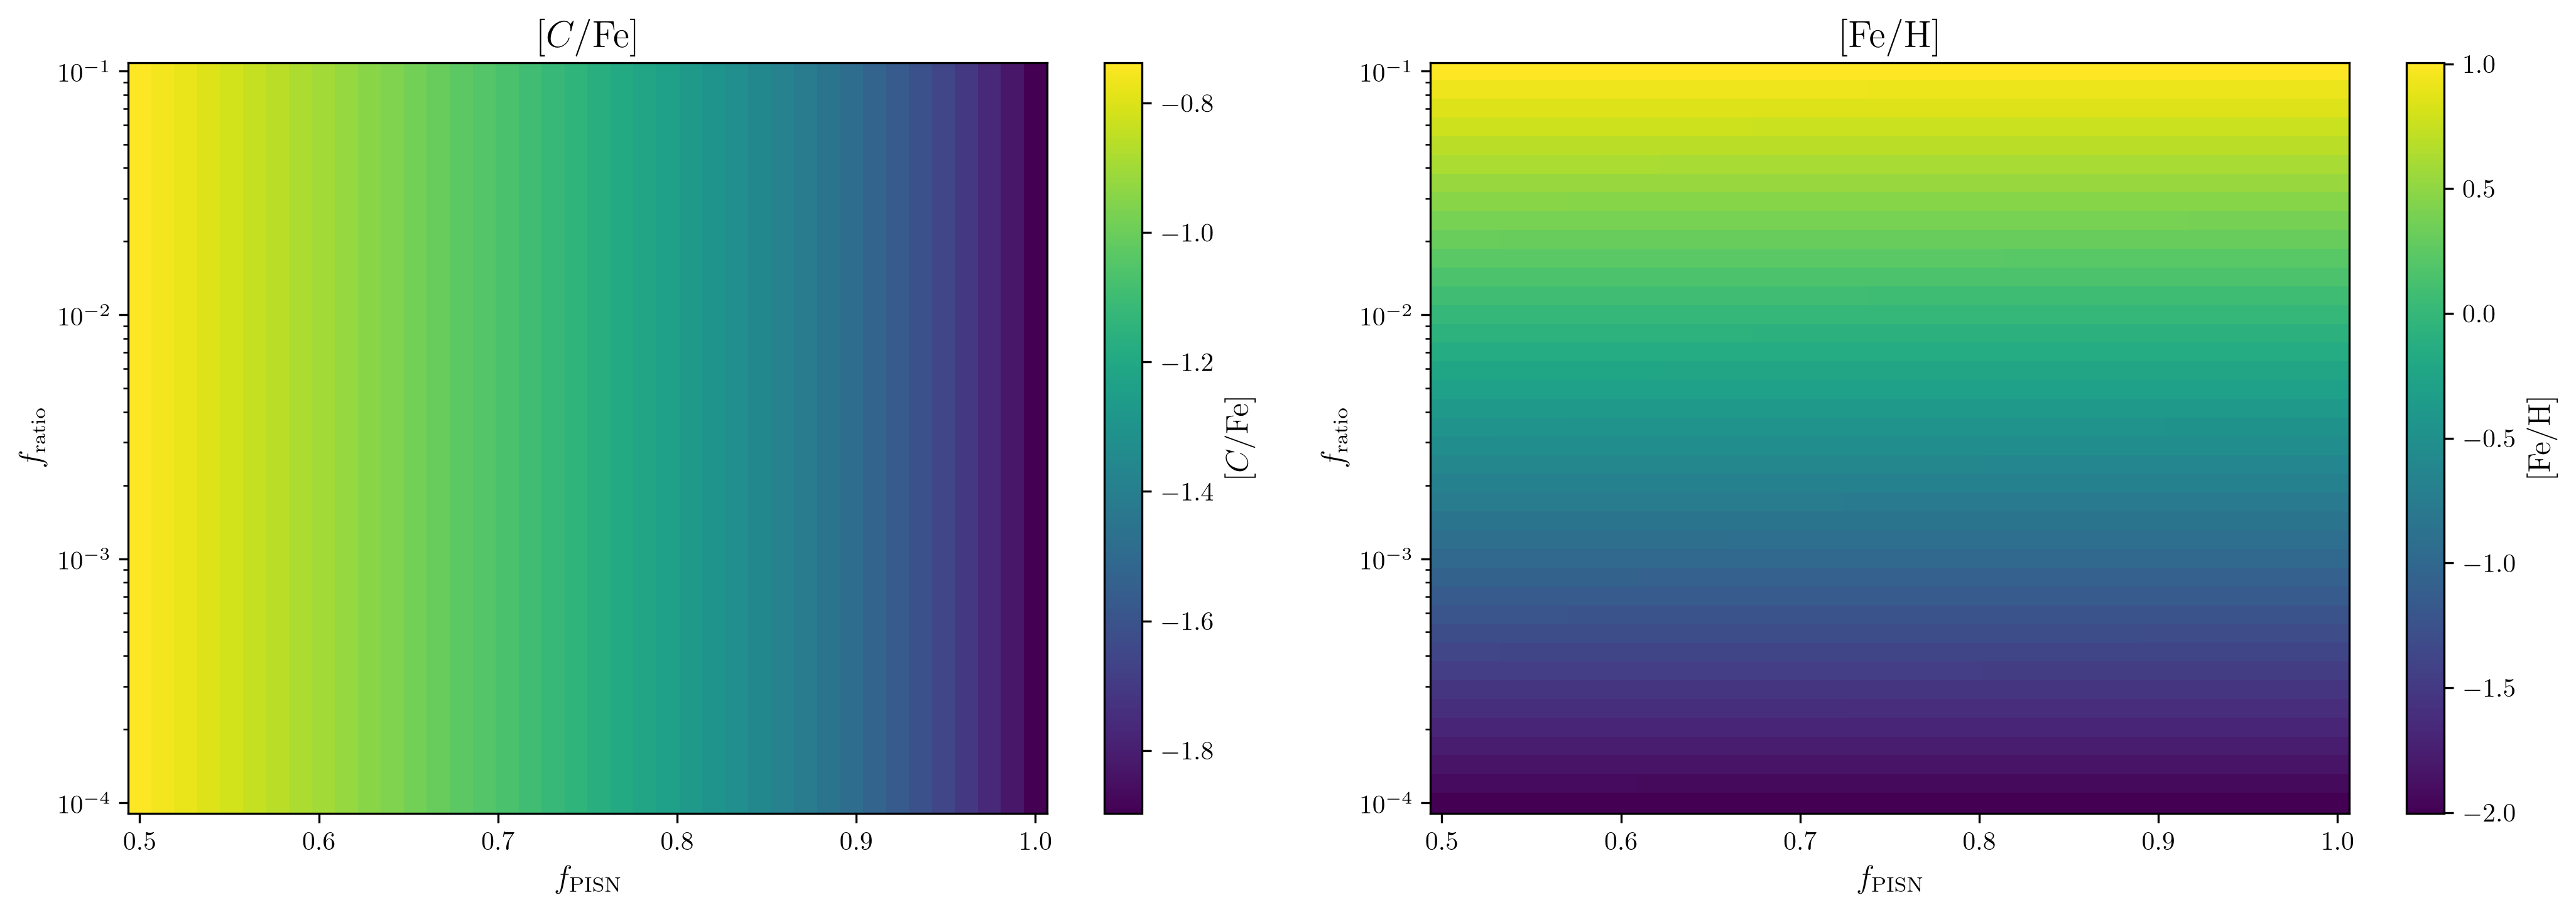

In [ ]:
pisn_yields = takahashi_yields
sn_yields = ishigaki18_selected_yields

pisn_entry = random.choice(pisn_yields)
sn_entry = random.choice(sn_yields)

f_pisn_span = np.linspace(0.5, 1.0, 40)
f_ratio_span = np.logspace(-4, -1, 40)

# make a 2d grid of f_pisn and f_ratio, and compute the abundance ratios for each combination

pisn_ratio_grid_X_Fe = np.zeros((len(f_pisn_span), len(f_ratio_span)))
pisn_ratio_grid_Fe_H = np.zeros((len(f_pisn_span), len(f_ratio_span)))

elem = "C"

for i, p in enumerate(f_pisn_span):
    for j, r in enumerate(f_ratio_span):
        ratio = salvadori_combined_abundratio(elem, elem, "Fe", "Fe", pisn_entry, sn_entry, f_pisn=p)
        ratio_h = salvadori_combined_abundratio_WrtH("Fe", "Fe", pisn_entry, sn_entry, f_pisn=p, f_ratio=r)
        pisn_ratio_grid_X_Fe[i, j] = ratio
        pisn_ratio_grid_Fe_H[i, j] = ratio_h

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# X/Fe
im1 = axes[0].pcolormesh(
    f_pisn_span,
    f_ratio_span,
    pisn_ratio_grid_X_Fe.T,
    shading="auto"
)

axes[0].set_xlabel(r"$f_{\rm PISN}$")
axes[0].set_ylabel(r"$f_{\rm ratio}$")
axes[0].set_yscale("log")
axes[0].set_title(rf"$[{elem}/\mathrm{{Fe}}]$")

cbar1 = fig.colorbar(im1, ax=axes[0])
cbar1.set_label(rf"$[{elem}/\mathrm{{Fe}}]$")


# Fe/H
im2 = axes[1].pcolormesh(
    f_pisn_span,
    f_ratio_span,
    pisn_ratio_grid_Fe_H.T,
    shading="auto"
)

axes[1].set_xlabel(r"$f_{\rm PISN}$")
axes[1].set_ylabel(r"$f_{\rm ratio}$")
axes[1].set_yscale("log")
axes[1].set_title(r"$[\mathrm{Fe}/\mathrm{H}]$")

cbar2 = fig.colorbar(im2, ax=axes[1])
cbar2.set_label(r"$[\mathrm{Fe}/\mathrm{H}]$")


plt.tight_layout()
plt.show()



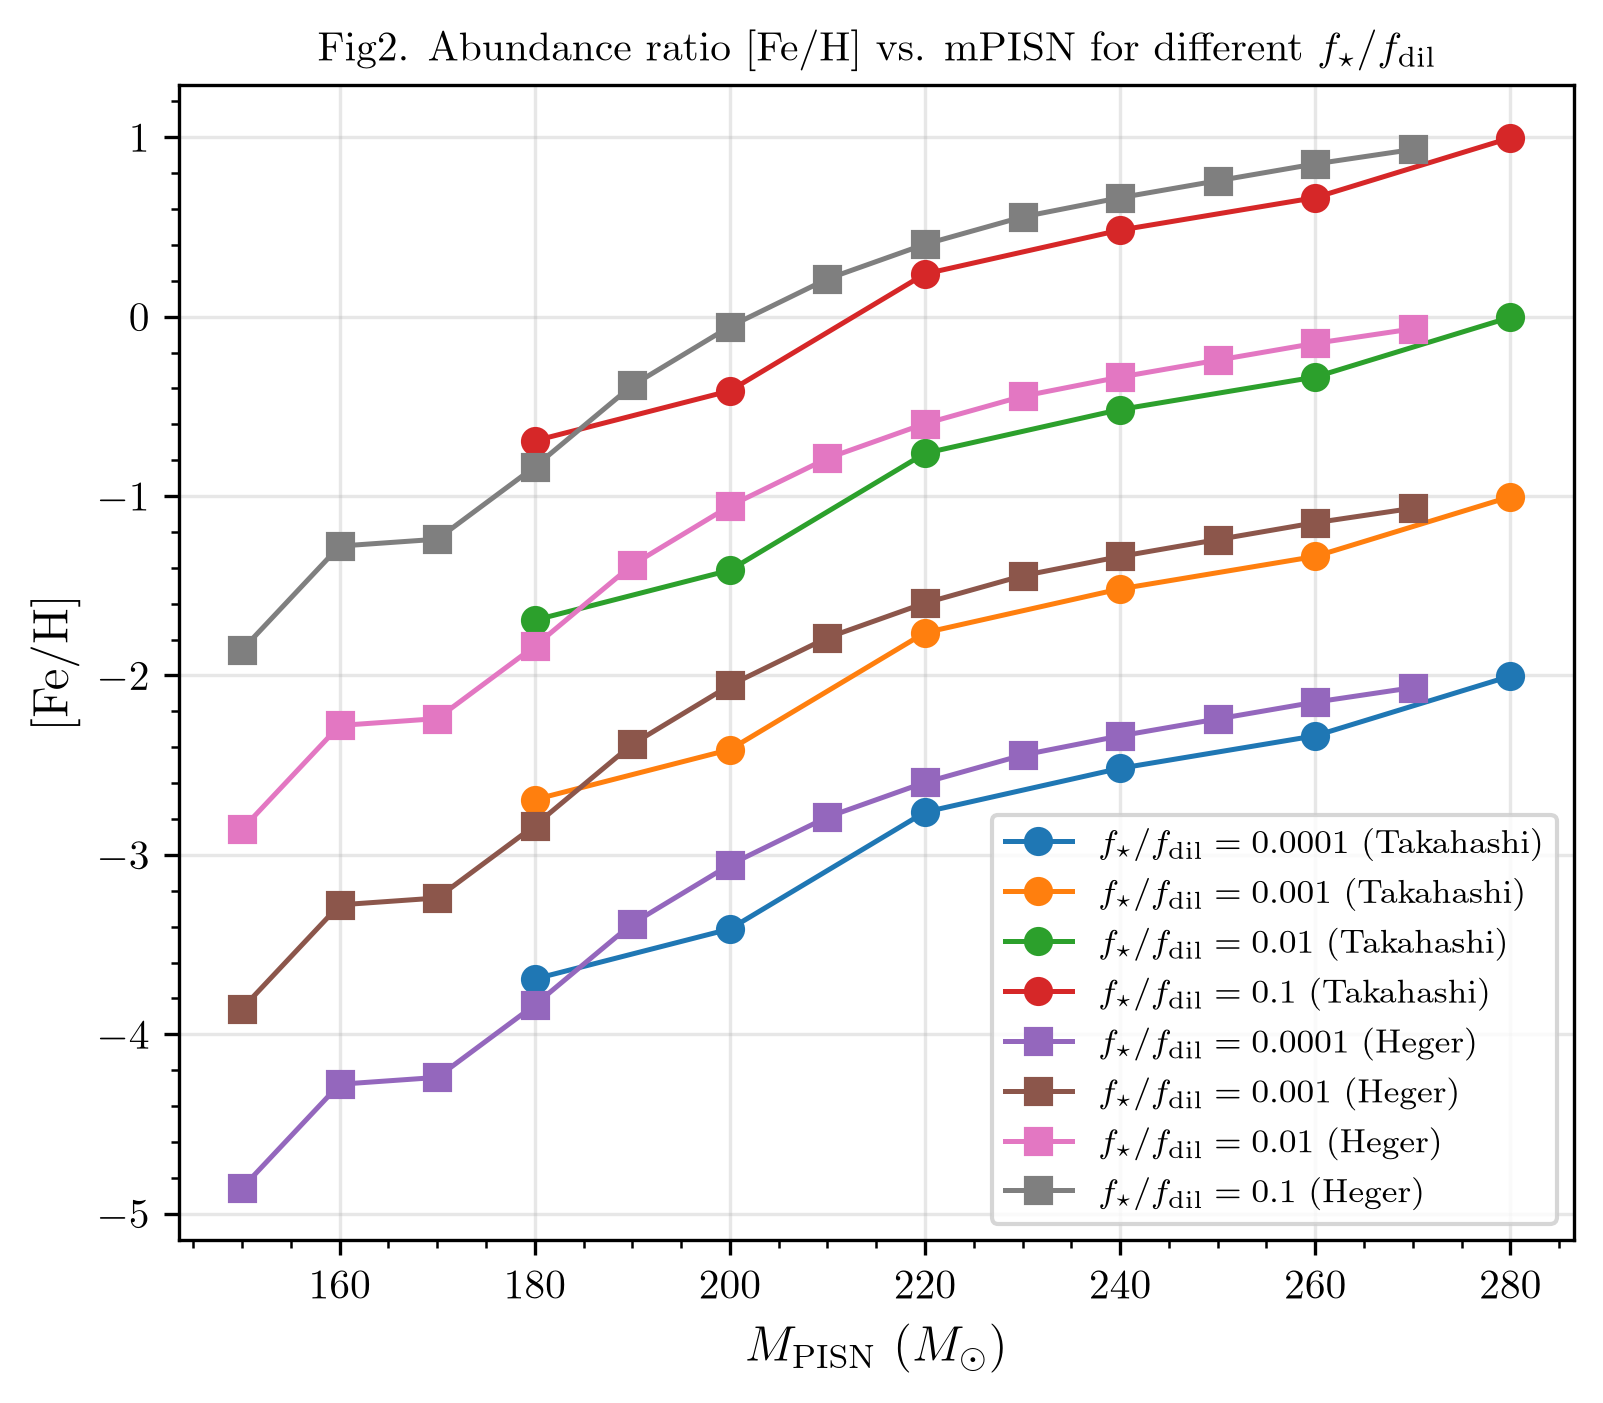

In [ ]:
# salvadori_yields = salvadori_yields_convert(takashi_yields)

sal_tk_yields = salvadori_yields_convert(takahashi_yields)
sal_hw_yields = salvadori_yields_convert(hw_yields)

fig2_values_tk = []
fig2_values_hw = []

for f_ratio in [1e-4, 1e-3, 1e-2, 1e-1]:
    Fe_H_to_mPISN = []

    for y in sal_tk_yields:
        mass = y["params"]["mass"]
        Fe_H = salvadori_H_ratio("Fe", f_ratio, y)
        Fe_H_to_mPISN.append((mass, Fe_H))

    fig2_values_tk.append((f_ratio, Fe_H_to_mPISN))

for f_ratio in [1e-4, 1e-3, 1e-2, 1e-1]:
    Fe_H_to_mPISN = []

    for y in sal_hw_yields:
        mass = y["params"]["mass"]
        Fe_H = salvadori_H_ratio("Fe", f_ratio, y)
        Fe_H_to_mPISN.append((mass, Fe_H))

    fig2_values_hw.append((f_ratio, Fe_H_to_mPISN))

fig, ax = plt.subplots(figsize=(6, 5))

for f_ratio, Fe_H_to_mPISN in fig2_values_tk:
    masses = np.array([m for m, _ in Fe_H_to_mPISN])
    fe_h = np.array([r for _, r in Fe_H_to_mPISN])
    ax.plot(masses, fe_h, marker="o", linewidth=1.2,
            label=rf"$f_\star/f_\mathrm{{dil}} = {f_ratio:g}$ (Takahashi)")
    

for f_ratio, Fe_H_to_mPISN in fig2_values_hw:
    masses = np.array([m for m, _ in Fe_H_to_mPISN])
    fe_h = np.array([r for _, r in Fe_H_to_mPISN])
    ax.plot(masses, fe_h, marker="s", linewidth=1.2,
            label=rf"$f_\star/f_\mathrm{{dil}} = {f_ratio:g}$ (Heger)")

ax.set_xlabel(r"$M_\mathrm{PISN}\ (M_\odot)$")
ax.set_ylabel(r"$[\mathrm{Fe}/\mathrm{H}]$")
ax.legend(fontsize=8)
fig.set_size_inches(6, 5)
ax.grid(True, alpha=0.3)
plt.minorticks_on()
plt.title(r"Fig2. Abundance ratio $[\mathrm{Fe}/\mathrm{H}]$ vs. mPISN for different $f_\star/f_\mathrm{dil}$", fontsize=10)
plt.show()


tpop2: 3000000.0, mPISN: 180, Fe/H: -2.691444194175854
tpop2: 3000000.0, mPISN: 200, Fe/H: -2.4131114849404884
tpop2: 3000000.0, mPISN: 220, Fe/H: -1.7613947179858152
tpop2: 3000000.0, mPISN: 240, Fe/H: -1.5174083579198172
tpop2: 3000000.0, mPISN: 260, Fe/H: -1.3363981169761907
tpop2: 3000000.0, mPISN: 280, Fe/H: -1.0036658827813334
tpop2: 6000000.0, mPISN: 180, Fe/H: -2.691331633535568
tpop2: 6000000.0, mPISN: 200, Fe/H: -2.413059913387066
tpop2: 6000000.0, mPISN: 220, Fe/H: -1.7613840997196546
tpop2: 6000000.0, mPISN: 240, Fe/H: -1.517402871454734


/home/ardo/mlem/Vaults/Thesis/Repl/src/salvadori_funcs.py:400: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return quad(


tpop2: 6000000.0, mPISN: 260, Fe/H: -1.3363948696261494
tpop2: 6000000.0, mPISN: 280, Fe/H: -1.0036644468810028
tpop2: 10000000.0, mPISN: 180, Fe/H: -2.691248765179676
tpop2: 10000000.0, mPISN: 200, Fe/H: -2.413019723580004
tpop2: 10000000.0, mPISN: 220, Fe/H: -1.76137554876388
tpop2: 10000000.0, mPISN: 240, Fe/H: -1.5173982602734182
tpop2: 10000000.0, mPISN: 260, Fe/H: -1.3363919978927765
tpop2: 10000000.0, mPISN: 280, Fe/H: -1.0036631451758316
tpop2: 20000000.0, mPISN: 180, Fe/H: -2.6909825602374653
tpop2: 20000000.0, mPISN: 200, Fe/H: -2.4128804508736303
tpop2: 20000000.0, mPISN: 220, Fe/H: -1.7613444524606294
tpop2: 20000000.0, mPISN: 240, Fe/H: -1.5173803885401667
tpop2: 20000000.0, mPISN: 260, Fe/H: -1.3363800053534851
tpop2: 20000000.0, mPISN: 280, Fe/H: -1.003657503497901
tpop2: 30000000.0, mPISN: 180, Fe/H: -2.6900842705905132
tpop2: 30000000.0, mPISN: 200, Fe/H: -2.412294297350062
tpop2: 30000000.0, mPISN: 220, Fe/H: -1.7611888431971752
tpop2: 30000000.0, mPISN: 240, Fe/H: -1

/home/ardo/mlem/Vaults/Thesis/Repl/src/salvadori_funcs.py:400: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return quad(


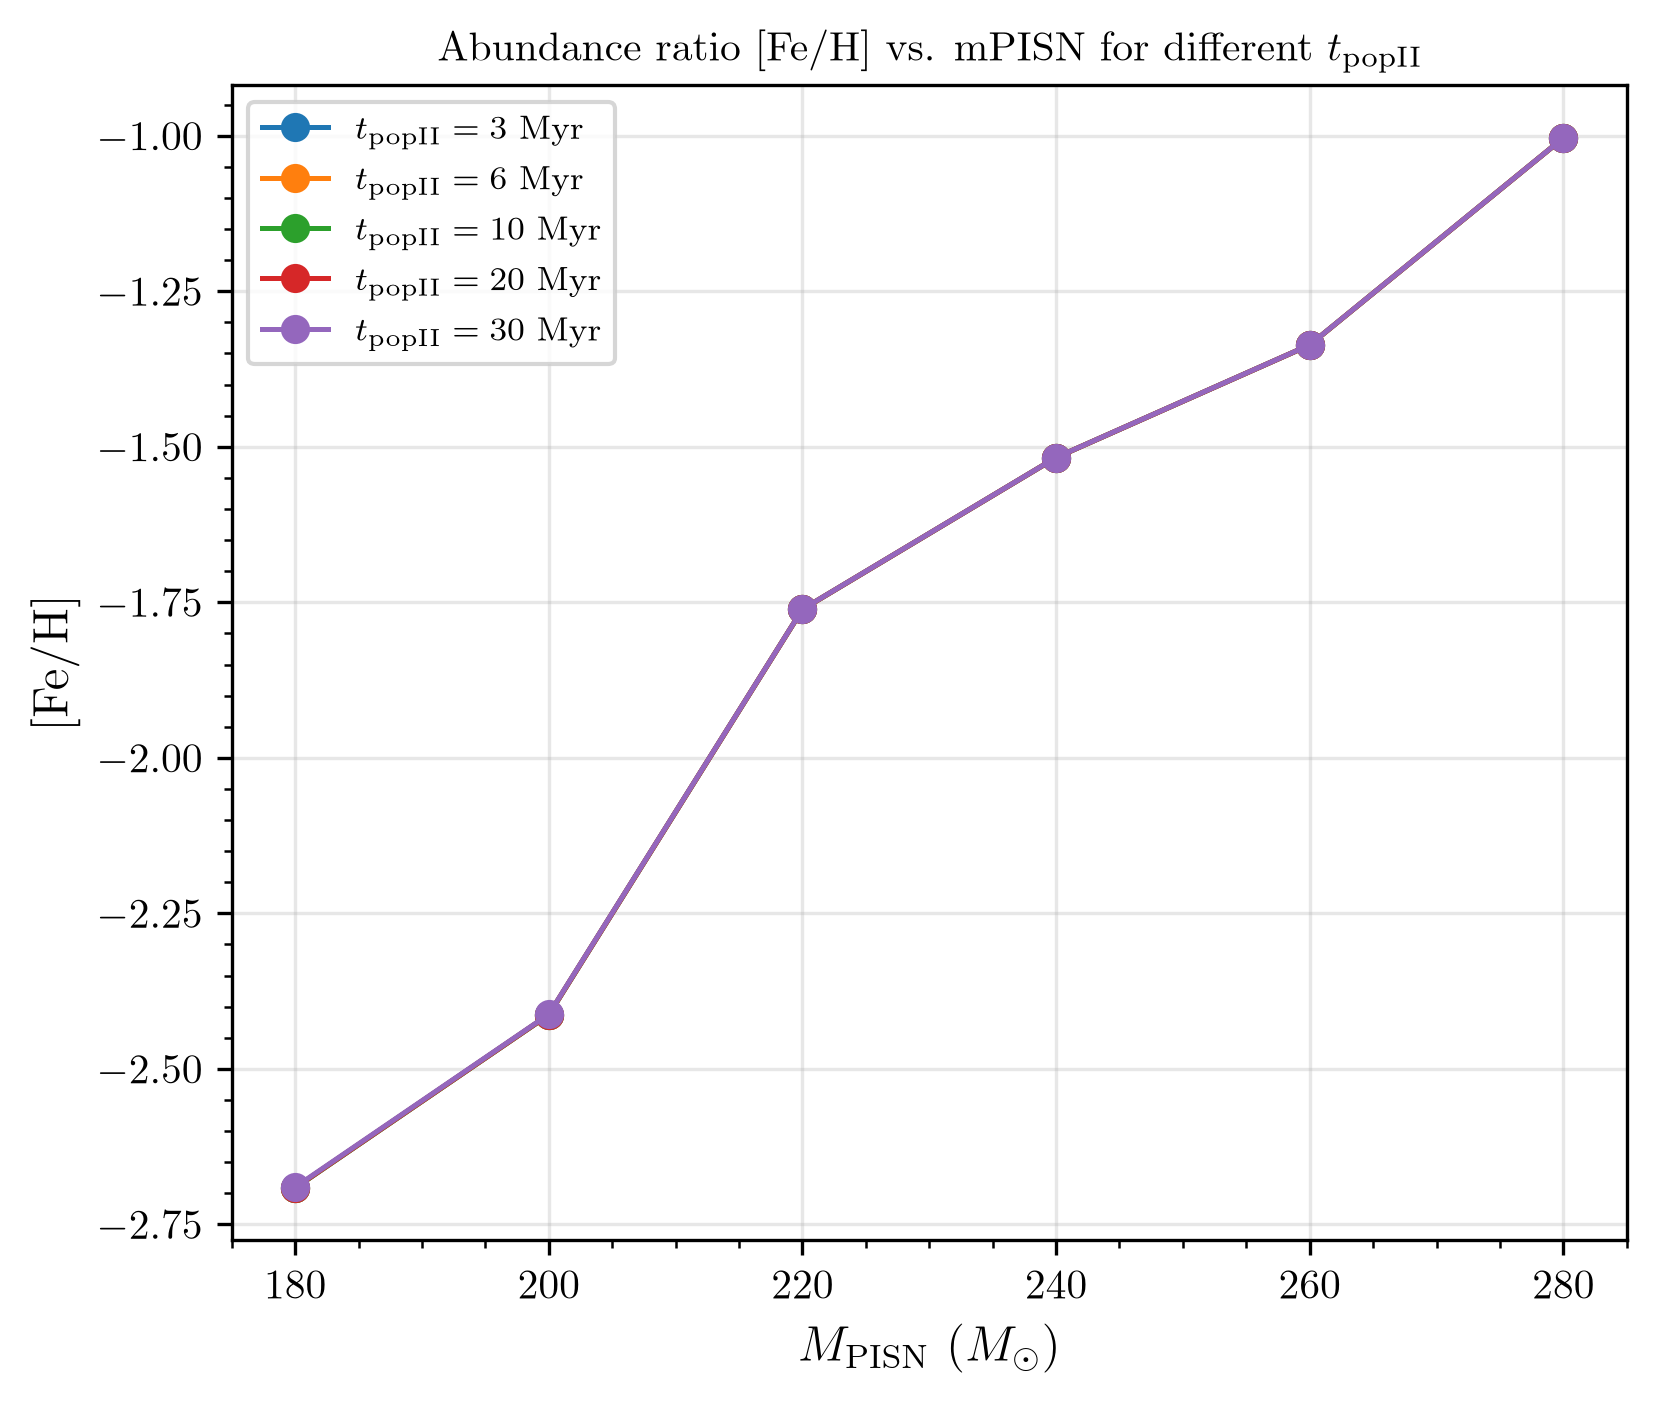

In [ ]:
pisn = pisn_yields[5]

from src.formulas import raiteri_mass_from_lifetime
from src.salvadori_funcs import salvadori_Y_X_II, salvadori_Y_Z_II

for t in [3e6, 6e6, 10e6, 20e6, 30e6]:

    Z_star = f_ratio * (
        sum(
            v
            for el, v in pisn["yields"].items()
            if el not in ("H", "He")
        )
        / pisn["params"]["mass"]
    )

    m_popII = raiteri_mass_from_lifetime(t, Z_star)

    YFe = salvadori_Y_X_II(
        data=sn_yields,
        elem="Fe",
        m_popII=m_popII,
        model="A",
        m_max=100.0,
    )

    YZ = salvadori_Y_Z_II(
        data=sn_yields,
        m_popII=m_popII,
        model="A",
        m_max=100.0,
    )

    print(
        f"{t/1e6:5.0f} Myr | "
        f"m_popII={m_popII:.3f} | "
        f"YFe={YFe:.8e} | "
        f"YZ={YZ:.8e} | "
        f"YFe/YZ={YFe/YZ:.8e}"
    )

    3 Myr | m_popII=15.705 | YFe=7.40800490e-05 | YZ=7.76866984e-03 | YFe/YZ=9.53574429e-03
    6 Myr | m_popII=9.495 | YFe=1.10269408e-04 | YZ=9.46477093e-03 | YFe/YZ=1.16505100e-02
   10 Myr | m_popII=7.104 | YFe=1.10247306e-04 | YZ=9.46507756e-03 | YFe/YZ=1.16477975e-02
   20 Myr | m_popII=5.077 | YFe=1.10241808e-04 | YZ=9.46566199e-03 | YFe/YZ=1.16464974e-02
   30 Myr | m_popII=4.260 | YFe=1.10245995e-04 | YZ=9.45010254e-03 | YFe/YZ=1.16661163e-02


/home/ardo/mlem/Vaults/Thesis/Repl/src/salvadori_funcs.py:400: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return quad(


In [ ]:
# ishigaki_yields = [
#     e for e in ishigaki18_yields if
#     # e["params"]["lfej"] == 0.0
#     # and
#     e["params"]["mass"] == 25
# ] 

4 peaks found
{'pisn': {'mass': 240}, 'sn': {'mass': 15.0, 'lfej': -3.0, 'energy': 1.0, 'elem_value': 5.0498e-09, 'Fe_value': 9.0305e-05}, 'ratios': {'C': np.float64(-0.9426966548069489), 'N': np.float64(-0.05807492995229735), 'O': np.float64(-0.0784756800380132), 'F': np.float64(-4.195938151523944), 'Ne': np.float64(-0.5296968765041663), 'Na': np.float64(-1.3214191644309703), 'Mg': np.float64(-0.35252164724729906), 'Al': np.float64(-1.4781606089100947), 'Si': np.float64(0.5193715874506325), 'S': np.float64(0.7310601218952746), 'Cl': np.float64(-1.2299729496164304), 'Ar': np.float64(0.6983658745835514), 'K': np.float64(-0.9174268202004795), 'Ca': np.float64(0.8170185430636554), 'Sc': np.float64(-1.4487874238953946), 'Ti': np.float64(-0.1440684071947178), 'V': np.float64(-0.7555515659171784), 'Cr': np.float64(0.3365918183503765), 'Mn': np.float64(-0.41020964492649425), 'Fe': np.float64(0.0), 'Co': np.float64(-1.4235924758020968), 'Ni': np.float64(-0.7417775819100045), 'Cu': np.float64(-

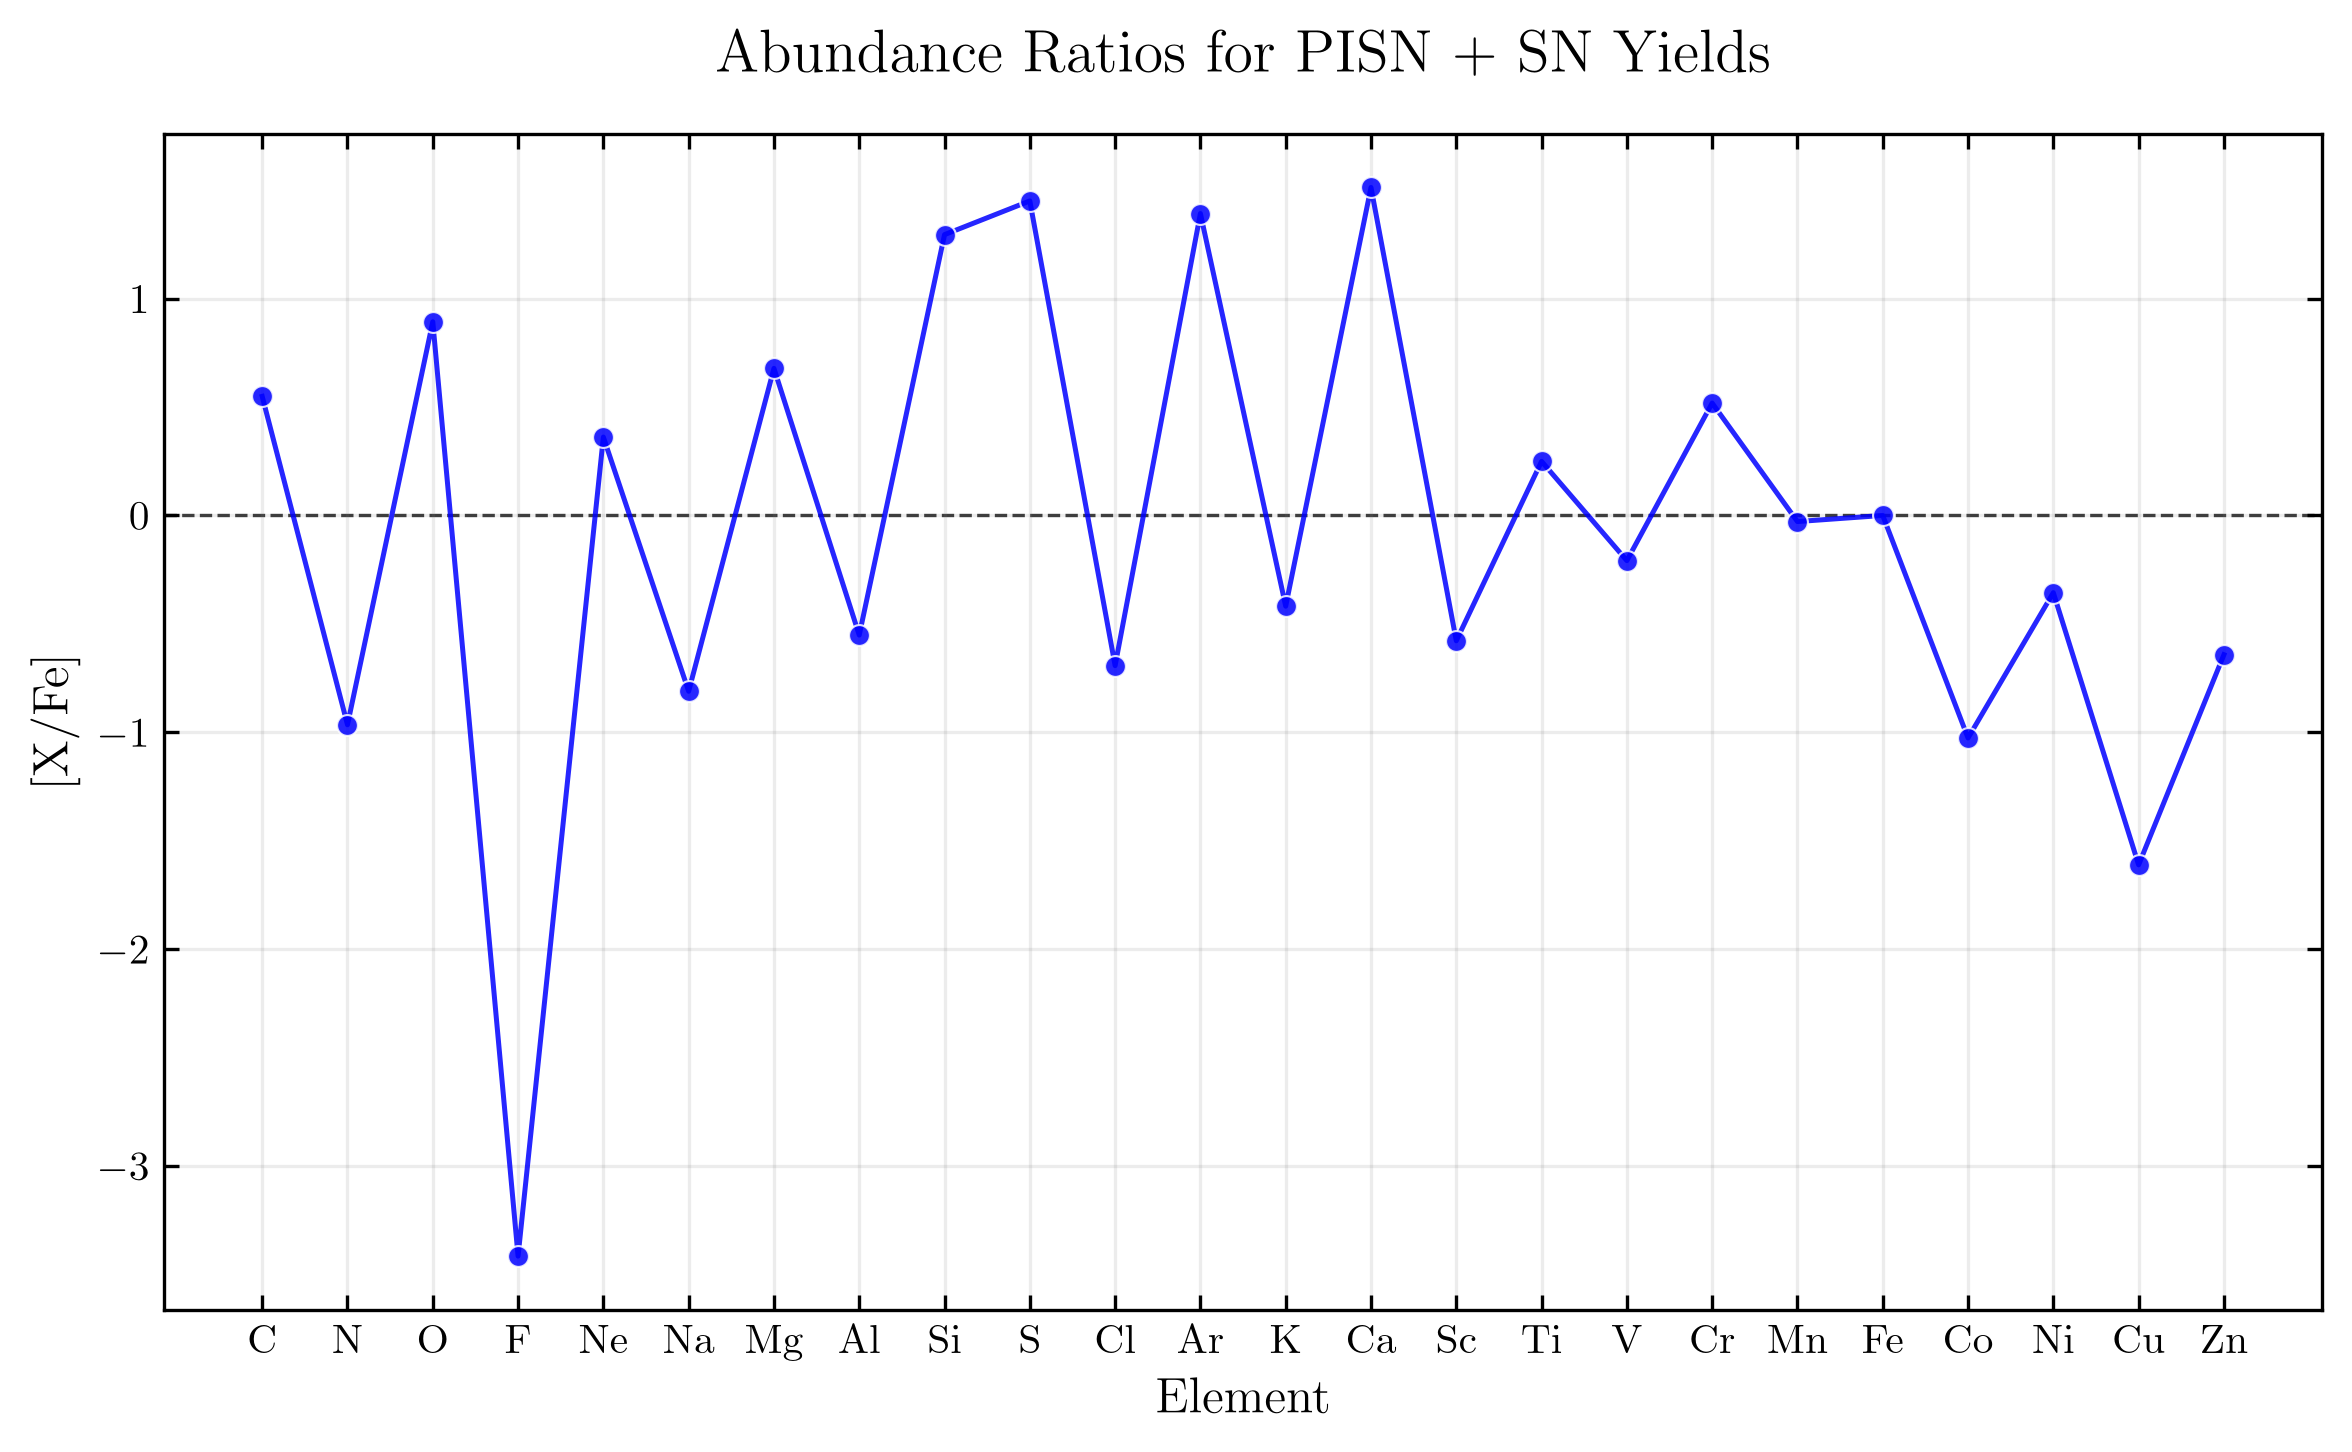

In [ ]:
X_fe_values = {}

pisn_entry = random.choice(pisn_yields)
sn_entry = random.choice(sn_yields)

f_pisn = 0.5

# for elem in filter_elements:
#     X_Fe_yield = salvadori_combined_abundratio(elem,elem,"Fe","Fe", pisn_entry, sn_entry, f_pisn=f_pisn)
#     X_fe_values[elem] = X_Fe_yield

# plot_one_yield(X_fe_values, title="Abundance Ratios for Random PISN and SN Yields", filter_elements=filter_elements)

peak_yield = extract_yield_peaks(pisn_yields, sn_yields, elem="Cu",f_pisn=0.9,f_ratio=1e-3,n_samples=1000)
print(len(peak_yield), "peaks found")
print(peak_yield[0])

plot_one_yield(peak_yield[1]["ratios"], title="Abundance Ratios for PISN + SN Yields", filter_elements=filter_elements)

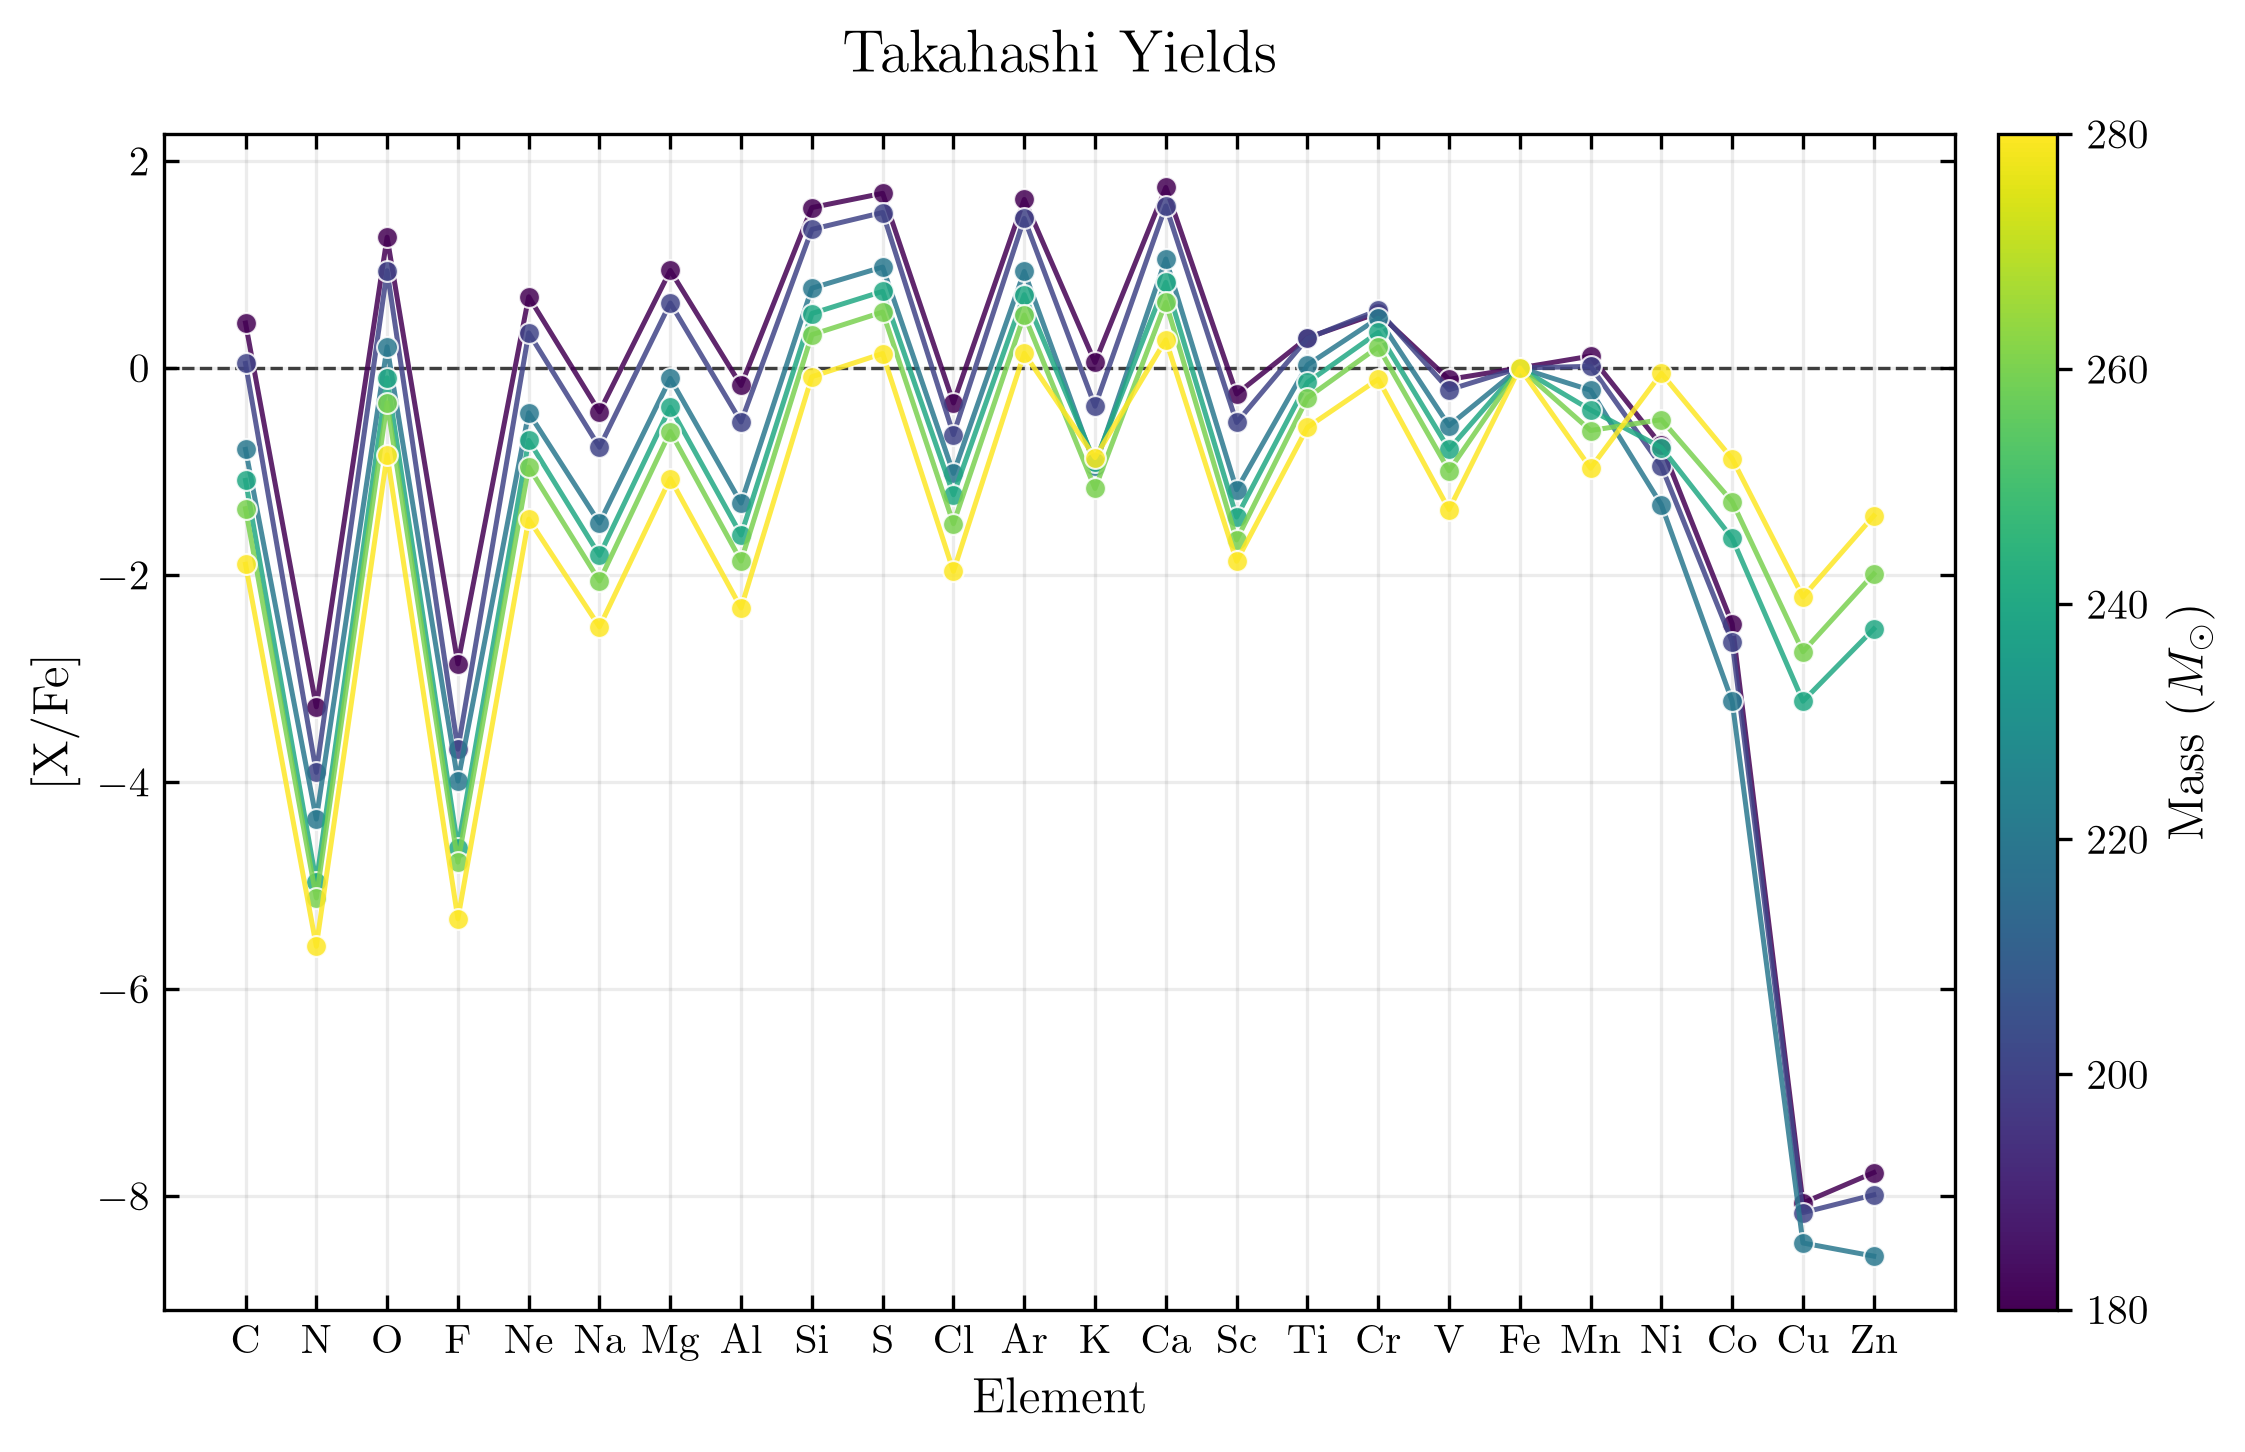

In [ ]:
plot_yields(takahashi_yields, title="Takahashi Yields", combine_elements=True, filter_elements=filter_elements)

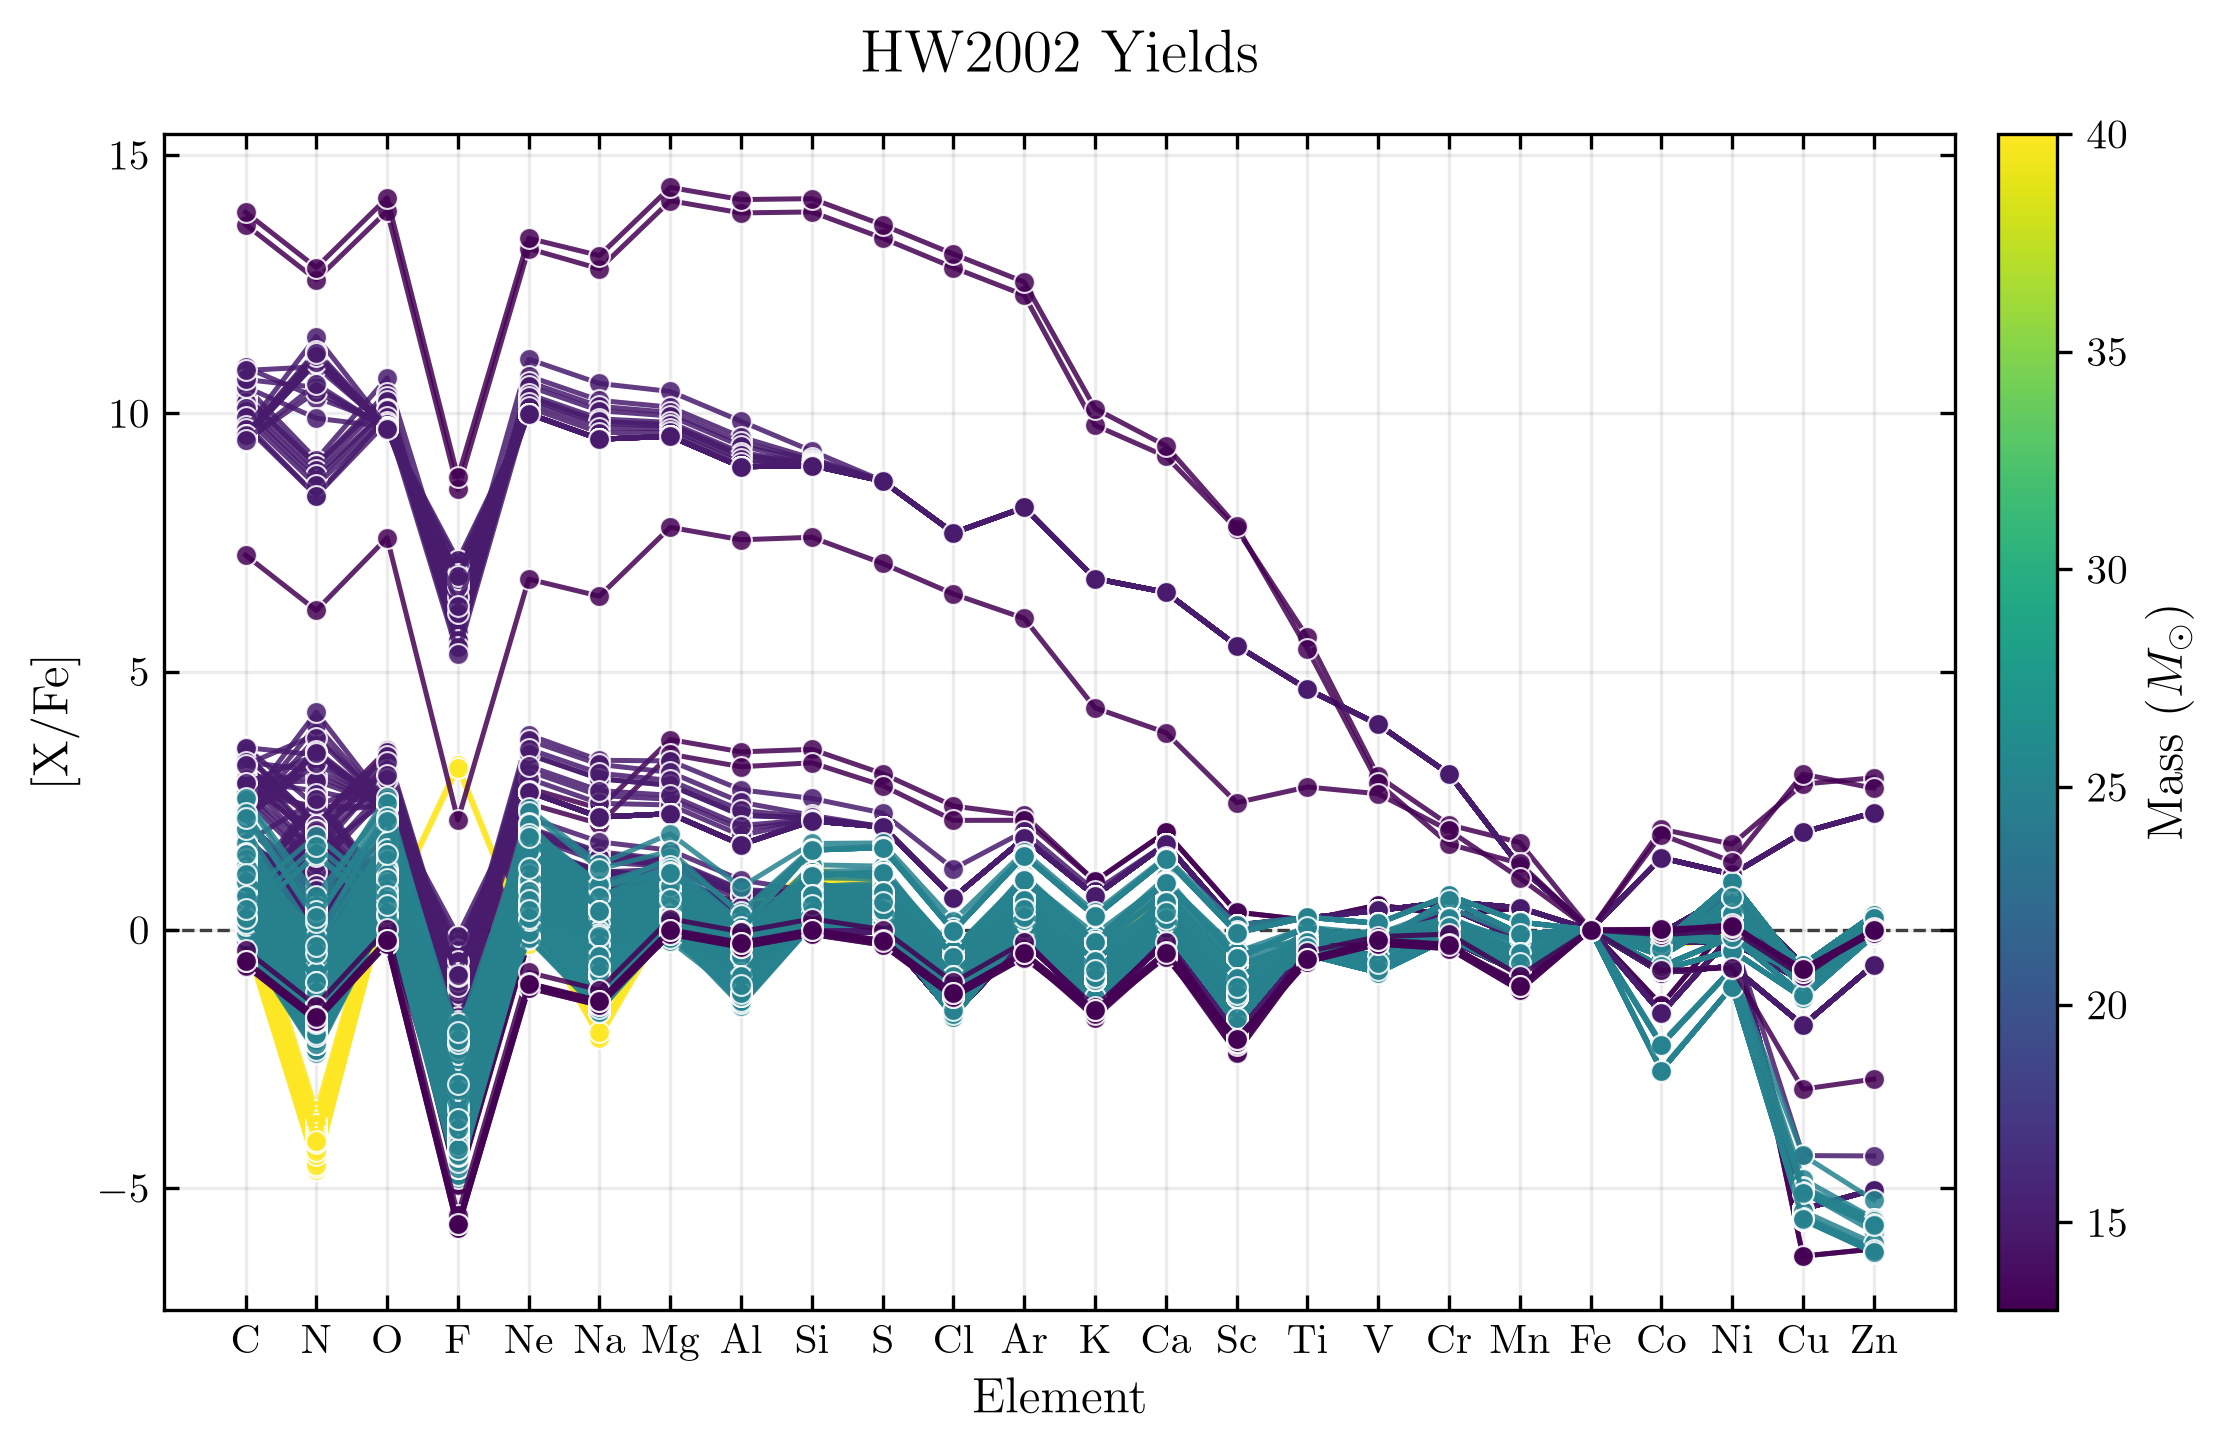

In [ ]:
plot_yields(ishigaki18_selected_yields, title="HW2002 Yields", combine_elements=True, filter_elements=filter_elements)

In [ ]:
# plot_yields(ishigaki_yields, title="Ishigaki 2018 Yields", combine_elements=True, filter_elements=filter_elements)